# Reservoir Computing — Group Project Notebook

This notebook is split into two parallel workstreams as agreed in the meeting:

- **Team A** — Reservoir Computing implementation on the Lorenz attractor
- **Team B** — Exploratory Data Analysis on the human brain connectivity dataset

Both teams converge at the end, where the trained reservoir is used on real network data.

---
# TEAM A — Reservoir Computing on the Lorenz Attractor

## Background

A **reservoir computer** (also called an Echo State Network, ESN) is a recurrent neural network where:
- The internal (recurrent) weights `W` are **fixed and random** — never trained
- Only the **output/readout weights** `W_out` are trained, via simple ridge regression

This makes training extremely fast and avoids vanishing/exploding gradient problems.

### The reservoir dynamics equation

$$\frac{d\vec{r}_i}{dt} = -r_i + \tanh\left(\sum_j W_{ij} r_j + \sum_j W^{\text{input}}_{ij} h_j(t)\right)$$

In discrete time with leaking rate `a`:

$$\vec{r}(t+1) = (1-a)\,\vec{r}(t) + a\,\tanh\!\left(W\,\vec{r}(t) + W^{\text{in}}\,\vec{u}(t)\right)$$

### The Lorenz attractor as input

The Lorenz system is a 3D chaotic dynamical system:

$$\dot{x} = \sigma(y - x), \qquad \dot{y} = x(\rho - z) - y, \qquad \dot{z} = xy - \beta z$$

We use the 3D trajectory $(x, y, z)(t)$ as the **3-channel input** to the reservoir. The goal is to train the reservoir to predict the **next state** $(x, y, z)(t + \Delta t)$.

## A1 — Utility Functions: `make_W` and `run_reservoir`

These helper functions allow us to build different types of weight matrices and run the autonomous (undriven) reservoir dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

# ─────────────────────────────────────────────────────────────
# Weight matrix factory
# kind options:
#   'gaussian'    – W_ij ~ N(0, J²/N)  → spectral radius ≈ J by Marchenko-Pastur
#   'full'        – all entries = J/N
#   'erdos_renyi' – random sparse graph, each edge has weight J/k
#   'data'        – use a provided connectivity matrix D, scaled by J
# ─────────────────────────────────────────────────────────────
def make_W(kind, N, J=1., p=None, D=None, rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "gaussian":
        # Entries ~ N(0, J²/N) → by random matrix theory the spectral
        # radius converges to J as N → ∞ (circular law)
        return rng.normal(0, J / np.sqrt(N), (N, N)).astype(dtype)
    if kind == "full":
        return np.full((N, N), J / N, dtype=dtype)
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(p * N, 1)          # expected degree
        return ((rng.random((N, N)) < p) * (J / k)).astype(dtype)
    if kind == "data":
        if D is None:
            raise ValueError("need D")
        return (J * np.asarray(D, dtype=dtype))
    raise ValueError("kind must be 'gaussian', 'full', 'erdos_renyi', or 'data'")


# ─────────────────────────────────────────────────────────────
# Initial state factory
# ─────────────────────────────────────────────────────────────
def init_r(N, kind="uniform", scale=1., rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "uniform":  return rng.uniform(-scale, scale, N).astype(dtype)
    if kind == "gaussian": return rng.normal(0, scale, N).astype(dtype)
    if kind == "zeros":    return np.zeros(N, dtype=dtype)
    if kind == "ones":     return np.ones(N, dtype=dtype)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")


# ─────────────────────────────────────────────────────────────
# Run the AUTONOMOUS reservoir (no external input)
#   dr/dt = -r + tanh(W r)   integrated with Euler step eps
# Returns M evenly-spaced snapshots of the N-dim state vector
# ─────────────────────────────────────────────────────────────
def run_reservoir(W, t, N=None, eps=1e-2, M=100, rng=None,
                  init="uniform", init_scale=1., dtype=np.float32):
    W = np.asarray(W, dtype=dtype)
    N = W.shape[0] if N is None else N
    steps = max(1, round(t / eps))
    if not (1 <= M <= steps):
        raise ValueError("need 1 <= M <= round(t/eps)")
    r    = init_r(N, kind=init, scale=init_scale, rng=rng, dtype=dtype)
    take = np.linspace(0, steps - 1, M, dtype=int)
    out, j = np.empty((M, N), dtype=dtype), 0
    for i in range(steps):
        r += eps * (-r + np.tanh(W @ r))
        if i == take[j]:
            out[j] = r
            j += 1
            if j == M:
                break
    return out

print("Utility functions loaded.")

Utility functions loaded.


## A2 — Quick sanity check: autonomous reservoir dynamics

Before adding input, we verify the reservoir settles into rich dynamics (not silent, not exploding).
We use a Gaussian W with spectral radius J = 1.2 (slightly above the edge of chaos at J = 1).

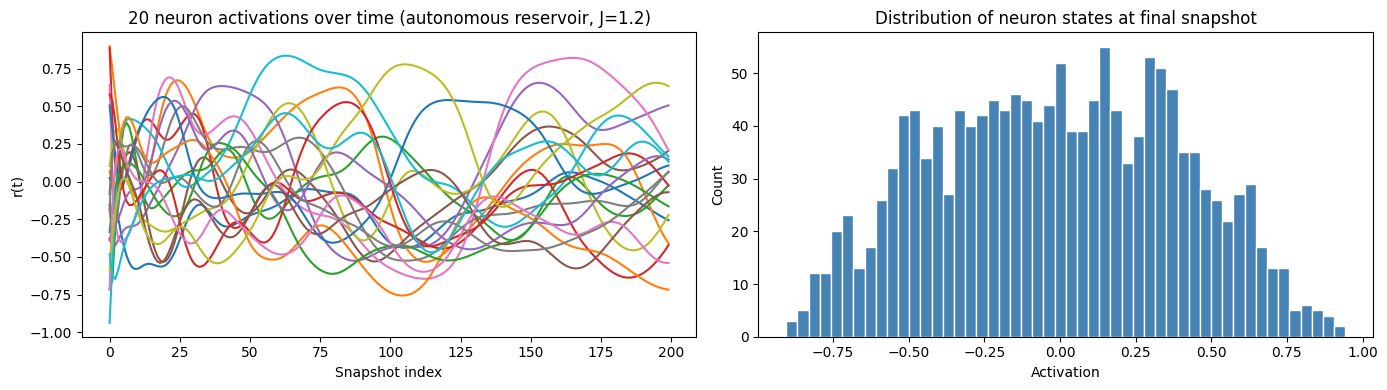

In [2]:
# Build a 1500-neuron Gaussian reservoir with J=1.2
W_test = make_W("gaussian", N=1500, J=1.2, rng=0)

# Run for t=100 time units, collect 200 snapshots
samples = run_reservoir(W_test, t=100.0, eps=1e-2, M=200, rng=1,
                        init="uniform", init_scale=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 20 random neuron traces over time
axes[0].plot(samples[:, :20])
axes[0].set_title("20 neuron activations over time (autonomous reservoir, J=1.2)")
axes[0].set_xlabel("Snapshot index")
axes[0].set_ylabel("r(t)")

# Distribution of final activations
axes[1].hist(samples[-1], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("Distribution of neuron states at final snapshot")
axes[1].set_xlabel("Activation")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## A3 — Generate the Lorenz Attractor

The Lorenz system will serve as both the **input signal** (driving the reservoir) and the **prediction target**.

Standard parameters: σ=10, ρ=28, β=8/3 → chaotic regime.

Lorenz data shape: (6000, 3)  (timesteps × dimensions)


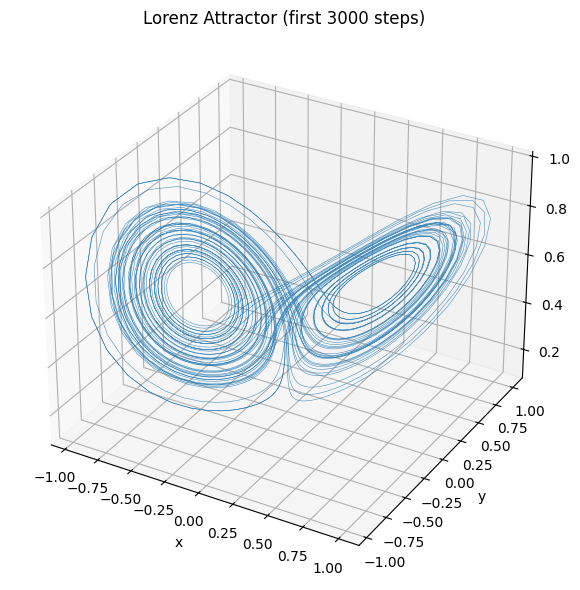

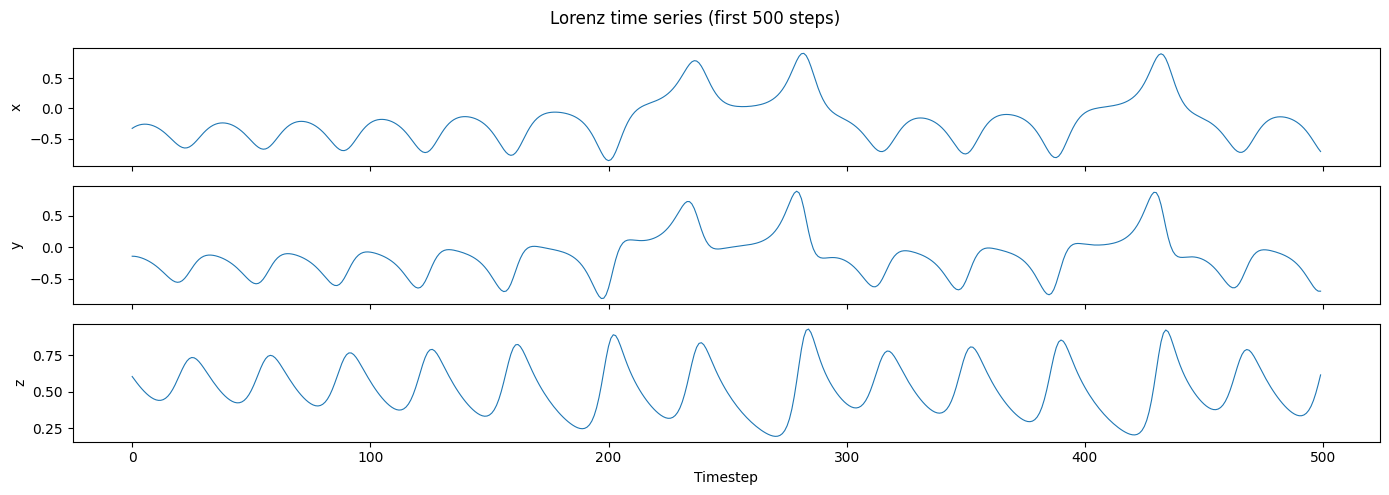

In [3]:
def lorenz(xyz, sigma=10., rho=28., beta=8./3.):
    """Return (dx/dt, dy/dt, dz/dt) given current state xyz."""
    x, y, z = xyz
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

def generate_lorenz(T, dt=0.02, warmup=500, x0=(0., 1., 1.05)):
    """
    Integrate the Lorenz system using RK4.
    - T      : number of timesteps to KEEP (after warmup)
    - dt     : integration timestep
    - warmup : steps discarded at the start (let it reach the attractor)
    Returns array of shape (T, 3): columns are x, y, z.
    """
    total = T + warmup
    traj  = np.zeros((total, 3))
    traj[0] = x0
    for i in range(total - 1):
        s  = traj[i]
        k1 = lorenz(s)
        k2 = lorenz(s + 0.5 * dt * k1)
        k3 = lorenz(s + 0.5 * dt * k2)
        k4 = lorenz(s + dt * k3)
        traj[i+1] = s + (dt / 6.) * (k1 + 2*k2 + 2*k3 + k4)
    return traj[warmup:]   # discard warmup

# Generate 6000 timesteps (dt=0.02 → ~120 time units)
dt      = 0.02
T_total = 6000
data_lorenz = generate_lorenz(T_total, dt=dt)  # shape (6000, 3)

# Normalise each dimension to [-1, 1] for cleaner reservoir dynamics
data_lorenz = data_lorenz / np.abs(data_lorenz).max(axis=0)

print(f"Lorenz data shape: {data_lorenz.shape}  (timesteps × dimensions)")

# ── 3D plot of the attractor ──────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(*data_lorenz[:3000].T, lw=0.4, alpha=0.8)
ax.set_title("Lorenz Attractor (first 3000 steps)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

# ── Time series of each component ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
for i, label in enumerate(['x', 'y', 'z']):
    axes[i].plot(data_lorenz[:500, i], lw=0.8)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Timestep")
fig.suptitle("Lorenz time series (first 500 steps)")
plt.tight_layout()
plt.show()

## A4 — Build the Echo State Network (ESN) Reservoir

Architecture:
- `N = 300` reservoir neurons
- Input dimension `inSize = 3` (the x, y, z Lorenz channels)
- Output dimension `outSize = 3` (predict the next x, y, z)
- Leaking rate `a = 0.3`
- Spectral radius scaled to `ρ = 0.95` (just below 1 for echo state property)

In [4]:
# ── Reservoir hyperparameters ─────────────────────────────────
N        = 300      # reservoir size (≤ 300 as per lecture)
inSize   = 3        # Lorenz input: (x, y, z)
outSize  = 3        # predict next (x, y, z)
a        = 0.3      # leaking rate
rho      = 0.95     # desired spectral radius  (< 1 → echo state property)
reg      = 1e-6     # ridge regression regularisation coefficient
reg      = 1e-6

# Train / test / init split
initLen  = 200      # warmup: reservoir states discarded
trainLen = 3000     # timesteps used for training
testLen  = 1000     # timesteps used for evaluation

rng = np.random.default_rng(42)

# ── Input weight matrix  W_in : shape (N, 1 + inSize) ────────
# The '1 +' adds a bias input unit (constant 1) to each neuron
Win = (rng.random((N, 1 + inSize)) - 0.5)  # uniform in [-0.5, 0.5]

# ── Recurrent weight matrix  W : shape (N, N) ─────────────────
W = rng.random((N, N)) - 0.5

# Scale W so its spectral radius equals rho
# (spectral radius = largest absolute eigenvalue)
print("Computing spectral radius of W...")
rhoW = max(abs(linalg.eig(W)[0]))
W   *= rho / rhoW
print(f"  Done. Spectral radius set to {rho}")

print(f"\nReservoir summary:")
print(f"  W    : {W.shape}")
print(f"  Win  : {Win.shape}")

Computing spectral radius of W...
  Done. Spectral radius set to 0.95

Reservoir summary:
  W    : (300, 300)
  Win  : (300, 4)


## A5 — Run the Reservoir (Data Collection Phase)

We drive the reservoir with the Lorenz signal.
At each timestep `t` we:
1. Feed `u(t) = (x,y,z)(t)` as input
2. Update the reservoir state `r(t+1) = (1-a)*r(t) + a*tanh(Win·[1;u] + W·r(t))`
3. After the `initLen` warmup, store the state in the design matrix `X`

The **design matrix** `X` has shape `(1 + inSize + N, trainLen - initLen)` — each column is `[bias; u(t); r(t)]`.

Design matrix X shape : (304, 2800)
Target matrix Yt shape: (3, 2800)


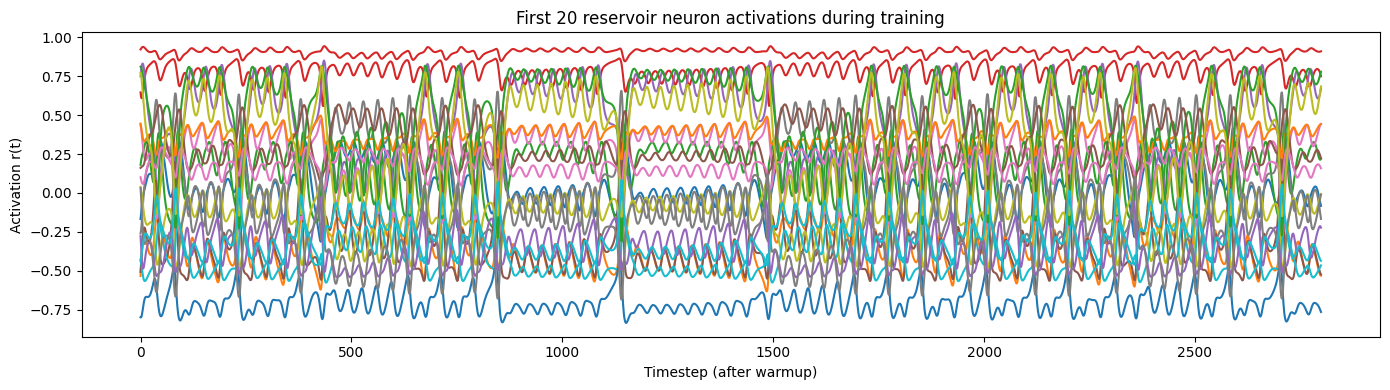

In [5]:
# Design matrix: rows = [1 bias | 3 input | N reservoir], cols = time
X  = np.zeros((1 + inSize + N,  trainLen - initLen))

# Target matrix: we want to predict the NEXT step (t + dt)
# Yt[:, k] = lorenz state at time initLen + k + 1
Yt = data_lorenz[initLen + 1 : trainLen + 1].T   # shape (3, trainLen-initLen)

# Run reservoir
r = np.zeros((N, 1))           # initial reservoir state = 0
for t in range(trainLen):
    u = data_lorenz[t].reshape(-1, 1)          # shape (3,1)
    bias_u = np.vstack([[1], u])               # shape (4,1) = [bias; x; y; z]
    r = (1 - a) * r + a * np.tanh(Win @ bias_u + W @ r)
    if t >= initLen:
        col = np.vstack([[1], u, r])[:, 0]    # shape (1+3+N,)
        X[:, t - initLen] = col

print(f"Design matrix X shape : {X.shape}")
print(f"Target matrix Yt shape: {Yt.shape}")

# Visualise some reservoir activations during training
plt.figure(figsize=(14, 4))
plt.plot(X[1 + inSize : 1 + inSize + 20, :].T)
plt.title("First 20 reservoir neuron activations during training")
plt.xlabel("Timestep (after warmup)")
plt.ylabel("Activation r(t)")
plt.tight_layout()
plt.show()

## A6 — Train the Readout Weights via Ridge Regression

We solve for `W_out` in:

$$W^{\text{out}} = Y_t X^T \left(X X^T + \lambda I\right)^{-1}$$

In practice we use `scipy.linalg.solve` which is more numerically stable than computing the explicit inverse.

W_out shape: (3, 304)


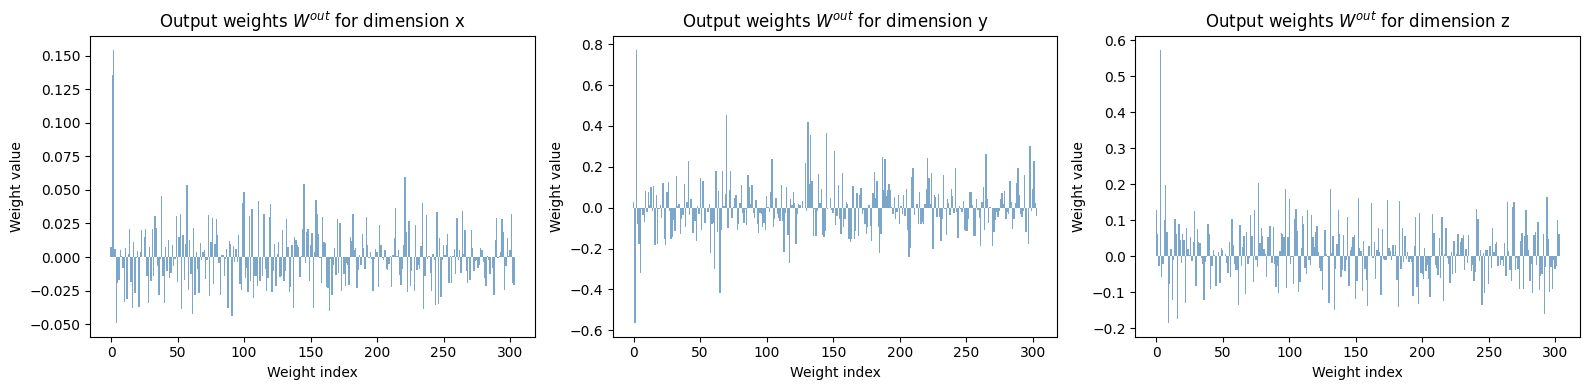

In [6]:
# Ridge regression: solve  (X X^T + λI) W_out^T = X Yt^T
A    = X @ X.T + reg * np.eye(1 + inSize + N)
B    = X @ Yt.T
Wout = linalg.solve(A, B).T          # shape (outSize=3, 1+inSize+N)

print(f"W_out shape: {Wout.shape}")

# Plot the readout weight distribution for each output neuron
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.bar(np.arange(Wout.shape[1]), Wout[i], width=1.0, color='steelblue', alpha=0.7)
    ax.set_title(f"Output weights $W^{{out}}$ for dimension {labels[i]}")
    ax.set_xlabel("Weight index")
    ax.set_ylabel("Weight value")
plt.tight_layout()
plt.show()

## A7 — Generative Mode: Autonomous Long-Term Prediction

After training, we switch to **generative (closed-loop) mode**:
- The reservoir's own output `ŷ(t)` is fed back as the next input `u(t+1)`
- No real data is used after the handover point `t₀ = trainLen`

A good reservoir should reproduce the **statistics and shape** of the Lorenz attractor, even if it diverges from the exact trajectory (which is expected for any chaotic system).

In [7]:
Y = np.zeros((outSize, testLen))
u = data_lorenz[trainLen].reshape(-1, 1)   # last known real input

for t in range(testLen):
    bias_u = np.vstack([[1], u])
    r      = (1 - a) * r + a * np.tanh(Win @ bias_u + W @ r)
    y      = Wout @ np.vstack([[1], u, r])  # linear readout
    Y[:, t] = y[:, 0]
    u = y                                   # ← GENERATIVE: feed output back as input
    # to switch to PREDICTIVE mode instead, use:
    # u = data_lorenz[trainLen + t + 1].reshape(-1, 1)

# ── MSE over first 500 test steps ────────────────────────────
errorLen = 500
target   = data_lorenz[trainLen + 1 : trainLen + errorLen + 1]   # (errorLen, 3)
pred     = Y[:, :errorLen].T                                      # (errorLen, 3)
mse      = np.mean((target - pred) ** 2)
mse_per  = np.mean((target - pred) ** 2, axis=0)
print(f"MSE (first {errorLen} steps):")
print(f"  Overall : {mse:.6f}")
print(f"  x       : {mse_per[0]:.6f}")
print(f"  y       : {mse_per[1]:.6f}")
print(f"  z       : {mse_per[2]:.6f}")

MSE (first 500 steps):
  Overall : 0.044497
  x       : 0.067180
  y       : 0.054419
  z       : 0.011893


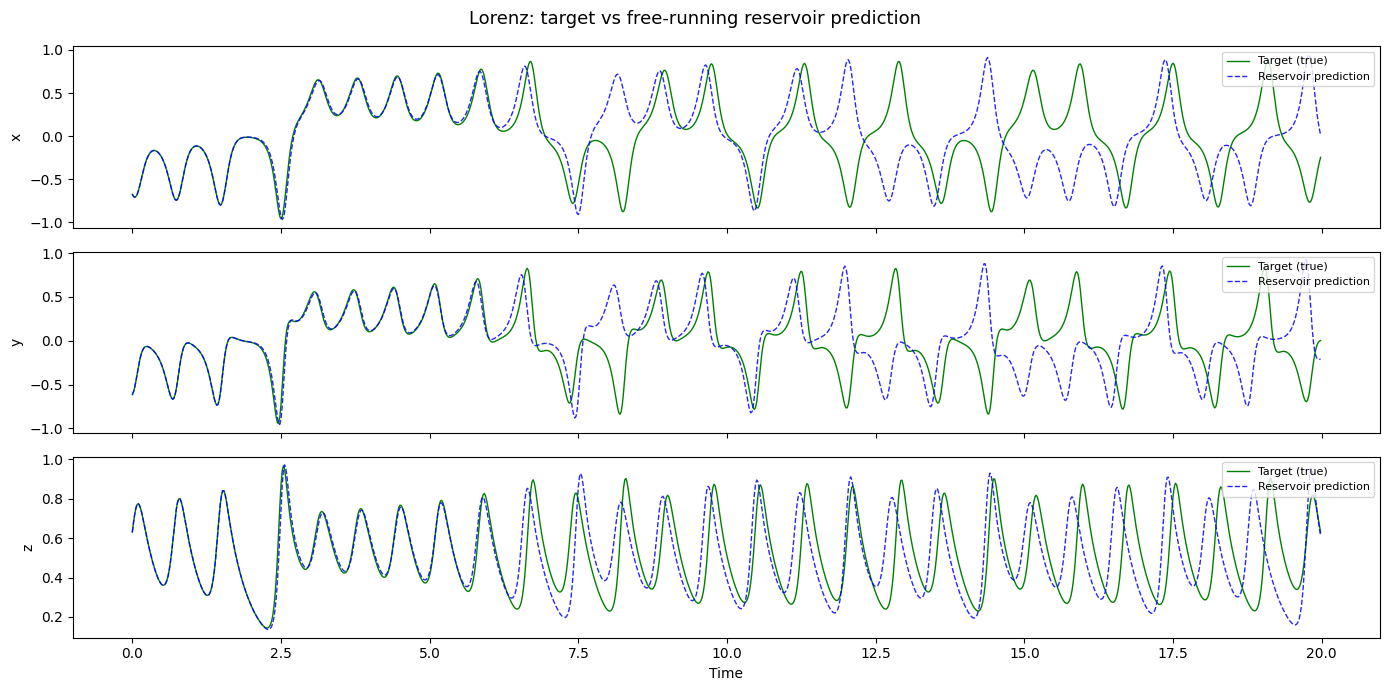

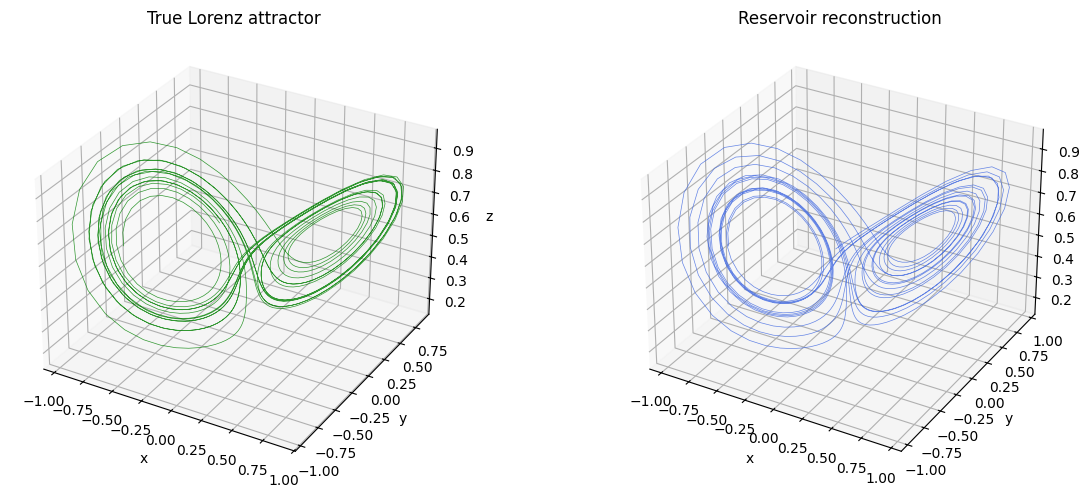

In [8]:
# ── Time-series comparison: target vs predicted ───────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
labels = ['x', 'y', 'z']
t_axis = np.arange(testLen) * dt
for i, ax in enumerate(axes):
    ax.plot(t_axis, data_lorenz[trainLen + 1 : trainLen + testLen + 1, i],
            'g', lw=1.0, label='Target (true)')
    ax.plot(t_axis, Y[i],
            'b--', lw=1.0, label='Reservoir prediction', alpha=0.85)
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time")
fig.suptitle("Lorenz: target vs free-running reservoir prediction", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3D attractor comparison ───────────────────────────────────
fig = plt.figure(figsize=(13, 5))
for idx, (traj, title, col) in enumerate([
    (data_lorenz[trainLen + 1 : trainLen + testLen + 1], "True Lorenz attractor",    'green'),
    (Y.T,                                                "Reservoir reconstruction", 'royalblue')
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    ax.plot(*traj.T, lw=0.5, color=col, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## A8 — Classic ESN Benchmark: Mackey-Glass (1D)

This is the original code from the meeting notes — a 1D scalar time-series benchmark using the **Mackey-Glass** chaotic sequence. It validates the ESN machinery independently of the Lorenz task.

In [9]:
# NOTE: requires 'MackeyGlass_t17.txt' in the working directory.
# Download from: http://minds.jacobs-university.de/sites/default/files/uploads/papers/MackeyGlass_t17.txt
# Or generate it — see comments below.

try:
    mg_data = np.loadtxt('MackeyGlass_t17.txt')
    print(f"Loaded Mackey-Glass data, length = {len(mg_data)}")
    
    trainLen_mg = 2000
    testLen_mg  = 2000
    initLen_mg  = 100
    inSize_mg   = outSize_mg = 1
    resSize_mg  = 1000
    a_mg        = 0.3

    rng_mg = np.random.default_rng(42)
    Win_mg = (rng_mg.random((resSize_mg, 1 + inSize_mg)) - 0.5)
    W_mg   =  rng_mg.random((resSize_mg, resSize_mg)) - 0.5

    print("Computing spectral radius (Mackey-Glass)...")
    rhoW_mg = max(abs(linalg.eig(W_mg)[0]))
    W_mg   *= 1.25 / rhoW_mg
    print("  Done.")

    X_mg  = np.zeros((1 + inSize_mg + resSize_mg, trainLen_mg - initLen_mg))
    Yt_mg = mg_data[None, initLen_mg + 1 : trainLen_mg + 1]

    x_mg = np.zeros((resSize_mg, 1))
    for t in range(trainLen_mg):
        u_mg  = mg_data[t]
        x_mg  = (1 - a_mg) * x_mg + a_mg * np.tanh(
                    Win_mg @ np.vstack([[1], [[u_mg]]]) + W_mg @ x_mg)
        if t >= initLen_mg:
            X_mg[:, t - initLen_mg] = np.vstack([[1], [[u_mg]], x_mg])[:, 0]

    reg_mg = 1e-8
    Wout_mg = linalg.solve(
        X_mg @ X_mg.T + reg_mg * np.eye(1 + inSize_mg + resSize_mg),
        X_mg @ Yt_mg.T
    ).T

    Y_mg = np.zeros((outSize_mg, testLen_mg))
    u_mg = mg_data[trainLen_mg]
    for t in range(testLen_mg):
        x_mg  = (1 - a_mg) * x_mg + a_mg * np.tanh(
                    Win_mg @ np.vstack([[1], [[u_mg]]]) + W_mg @ x_mg)
        y_mg  = Wout_mg @ np.vstack([[1], [[u_mg]], x_mg])
        Y_mg[:, t] = y_mg
        u_mg = y_mg  # generative mode

    errorLen_mg = 500
    mse_mg = np.sum(
        (mg_data[trainLen_mg + 1 : trainLen_mg + errorLen_mg + 1]
         - Y_mg[0, :errorLen_mg]) ** 2) / errorLen_mg
    print(f"Mackey-Glass MSE = {mse_mg:.2e}")

    plt.figure(figsize=(14, 4))
    plt.plot(mg_data[trainLen_mg + 1 : trainLen_mg + testLen_mg + 1], 'g', label='Target')
    plt.plot(Y_mg.T, 'b--', alpha=0.85, label='Predicted')
    plt.title('Mackey-Glass: target vs free-running prediction')
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("⚠️  MackeyGlass_t17.txt not found — skipping this cell.")
    print("   Download it from: http://minds.jacobs-university.de/sites/default/files/uploads/papers/MackeyGlass_t17.txt")

⚠️  MackeyGlass_t17.txt not found — skipping this cell.
   Download it from: http://minds.jacobs-university.de/sites/default/files/uploads/papers/MackeyGlass_t17.txt


---
# TEAM B — Exploratory Data Analysis: Human Brain Connectivity Dataset

## Background

The human dataset represents a **brain connectivity graph**: nodes are brain regions and edges represent the strength of structural or functional connections between them.

Our goals (as specified in the meeting):
1. Understand the **degree distribution** of nodes
2. Detect **clusters/communities** in the network
3. Broad **exploratory data analysis** using NetworkX

> **To use with your actual dataset**: replace the synthetic graph generation below with your real data loading step. The analysis cells work on any NetworkX graph `G`.

In [10]:
try:
    import networkx as nx
    from networkx.algorithms import community
    print(f"NetworkX version: {nx.__version__}")
except ImportError:
    print("Installing networkx...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx", "-q"])
    import networkx as nx
    from networkx.algorithms import community

from collections import Counter

NetworkX version: 3.6.1


## B1 — Load the Dataset

Replace the block below with your real data loader.
The rest of the notebook expects a NetworkX graph `G`.

In [11]:
# ──────────────────────────────────────────────────────────────
# OPTION A  — Load from edge-list file (most common format)
# ──────────────────────────────────────────────────────────────
# G = nx.read_edgelist('your_dataset.txt', nodetype=int,
#                      data=[("weight", float)])

# ──────────────────────────────────────────────────────────────
# OPTION B — Load from adjacency matrix (numpy .npy or .csv)
# ──────────────────────────────────────────────────────────────
# A = np.load('connectivity_matrix.npy')
# G = nx.from_numpy_array(A)

# ──────────────────────────────────────────────────────────────
# PLACEHOLDER — synthetic scale-free graph for demonstration
# Replace with your real data above!
# ──────────────────────────────────────────────────────────────
print("⚠️  Using a synthetic Barabási-Albert scale-free graph as placeholder.")
print("   Replace this cell with your real dataset loader.")
G = nx.barabasi_albert_graph(n=200, m=3, seed=42)

print(f"\nGraph loaded:")
print(f"  Nodes : {G.number_of_nodes()}")
print(f"  Edges : {G.number_of_edges()}")
print(f"  Directed : {G.is_directed()}")

⚠️  Using a synthetic Barabási-Albert scale-free graph as placeholder.
   Replace this cell with your real dataset loader.

Graph loaded:
  Nodes : 200
  Edges : 591
  Directed : False


## B2 — Basic Graph Statistics

In [12]:
N_nodes = G.number_of_nodes()
N_edges = G.number_of_edges()
density = nx.density(G)
avg_deg = sum(dict(G.degree()).values()) / N_nodes

# Check connectivity
is_connected = nx.is_connected(G) if not G.is_directed() else nx.is_weakly_connected(G)

# Average clustering coefficient (triangle density around each node)
avg_clustering = nx.average_clustering(G)

# Average shortest path (only meaningful if connected; sample if large)
if is_connected and N_nodes <= 1000:
    avg_path = nx.average_shortest_path_length(G)
else:
    # Sample-based estimate for large/disconnected graphs
    sampled_nodes = list(G.nodes)[:100]
    lengths = []
    for n in sampled_nodes:
        sp = nx.single_source_shortest_path_length(G, n)
        lengths.extend(sp.values())
    avg_path = np.mean([l for l in lengths if l > 0])
    print("  (avg path estimated from 100-node sample)")

print("=" * 40)
print("      GRAPH SUMMARY STATISTICS")
print("=" * 40)
print(f"  Nodes                : {N_nodes}")
print(f"  Edges                : {N_edges}")
print(f"  Density              : {density:.4f}")
print(f"  Mean degree          : {avg_deg:.2f}")
print(f"  Connected            : {is_connected}")
print(f"  Avg clustering coeff : {avg_clustering:.4f}")
print(f"  Avg shortest path    : {avg_path:.4f}")
print("=" * 40)

      GRAPH SUMMARY STATISTICS
  Nodes                : 200
  Edges                : 591
  Density              : 0.0297
  Mean degree          : 5.91
  Connected            : True
  Avg clustering coeff : 0.1023
  Avg shortest path    : 2.8346


## B3 — Degree Distribution

The **degree** of a node is the number of connections it has.

- **Poisson distribution** → Erdős–Rényi random graphs
- **Power law** `p(k) ~ k^{-α}` with `2 ≤ α ≤ 3` → scale-free (real-world brain networks)

Power-law exponent fit: α ≈ 1.549  (expect 2–3 for scale-free)


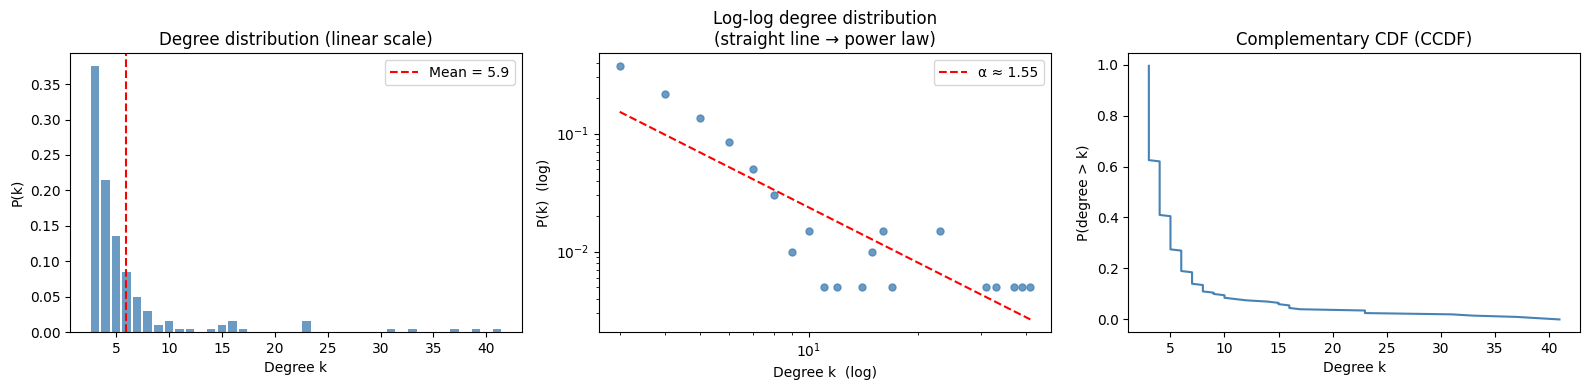


Degree statistics:
  Min    : 3
  Max    : 41
  Mean   : 5.91
  Median : 4
  Std    : 5.99


In [13]:
degrees     = sorted(dict(G.degree()).values())
deg_count   = Counter(degrees)
deg_vals    = np.array(sorted(deg_count.keys()))
deg_freqs   = np.array([deg_count[k] for k in deg_vals])
deg_probs   = deg_freqs / deg_freqs.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Linear scale histogram ─────────────────────────────────────
axes[0].bar(deg_vals, deg_probs, width=0.8, color='steelblue', alpha=0.8)
axes[0].set_xlabel("Degree k")
axes[0].set_ylabel("P(k)")
axes[0].set_title("Degree distribution (linear scale)")
axes[0].axvline(np.mean(degrees), color='red', ls='--', label=f"Mean = {np.mean(degrees):.1f}")
axes[0].legend()

# ── Log-log scale (power-law check) ───────────────────────────
axes[1].loglog(deg_vals[deg_probs > 0], deg_probs[deg_probs > 0],
               'o', ms=5, color='steelblue', alpha=0.8)
axes[1].set_xlabel("Degree k  (log)")
axes[1].set_ylabel("P(k)  (log)")
axes[1].set_title("Log-log degree distribution\n(straight line → power law)")

# Fit a power law on the log-log tail
mask = deg_vals >= 2
if mask.sum() >= 3:
    log_k = np.log(deg_vals[mask & (deg_probs > 0)])
    log_p = np.log(deg_probs[mask & (deg_probs > 0)])
    coeffs = np.polyfit(log_k, log_p, 1)
    alpha_fit = -coeffs[0]
    fit_line = np.exp(np.polyval(coeffs, log_k))
    axes[1].loglog(np.exp(log_k), fit_line, 'r--', lw=1.5, label=f"α ≈ {alpha_fit:.2f}")
    axes[1].legend()
    print(f"Power-law exponent fit: α ≈ {alpha_fit:.3f}  (expect 2–3 for scale-free)")

# ── Cumulative degree distribution ────────────────────────────
sorted_degs = np.sort(degrees)
cdf         = np.arange(1, len(sorted_degs) + 1) / len(sorted_degs)
axes[2].plot(sorted_degs, 1 - cdf, color='steelblue')
axes[2].set_xlabel("Degree k")
axes[2].set_ylabel("P(degree > k)")
axes[2].set_title("Complementary CDF (CCDF)")

plt.tight_layout()
plt.show()

print(f"\nDegree statistics:")
print(f"  Min    : {min(degrees)}")
print(f"  Max    : {max(degrees)}")
print(f"  Mean   : {np.mean(degrees):.2f}")
print(f"  Median : {np.median(degrees):.0f}")
print(f"  Std    : {np.std(degrees):.2f}")

## B4 — Community Detection

We use the **Louvain algorithm** (via NetworkX) to find communities, as mentioned in the lecture and meeting notes.

Louvain maximises **modularity** Q — a measure of how much denser within-community edges are compared to a random baseline.

Communities found  : 9
Modularity Q       : 0.3699  (>0.3 = meaningful structure)
Community sizes    : [34, 30, 29, 24, 22, 21, 18, 13, 9]


/tmp/ipykernel_140940/4022140171.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', n_communities)


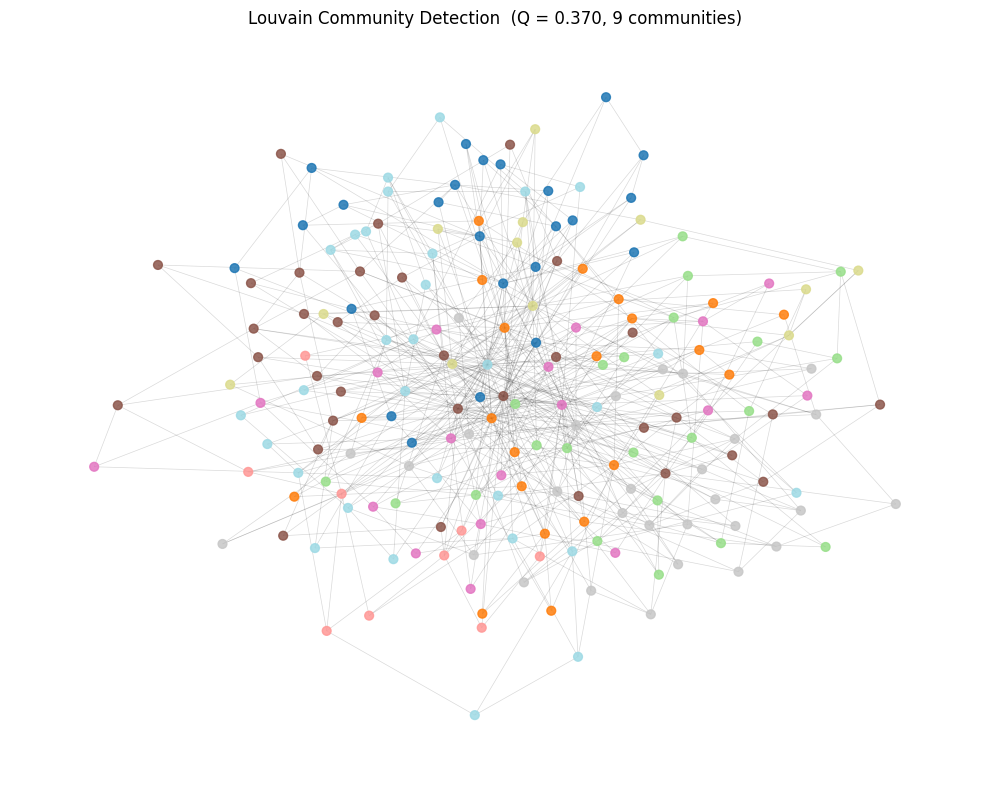

In [14]:
# Louvain community detection
communities = nx.community.louvain_communities(G, seed=42)
n_communities = len(communities)

# Modularity score
modularity = nx.community.modularity(G, communities)

print(f"Communities found  : {n_communities}")
print(f"Modularity Q       : {modularity:.4f}  (>0.3 = meaningful structure)")
print(f"Community sizes    : {sorted([len(c) for c in communities], reverse=True)}")

# Build a node → community-id mapping
node_community = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_community[node] = cid

# Colour nodes by community and draw the graph
cmap   = plt.cm.get_cmap('tab20', n_communities)
colors = [cmap(node_community[n]) for n in G.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.3)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=40, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)
plt.title(f"Louvain Community Detection  (Q = {modularity:.3f}, {n_communities} communities)")
plt.axis('off')
plt.tight_layout()
plt.show()

## B5 — Node Centrality Analysis

Centrality measures identify the most **important/connected** nodes (brain hubs).

Top 10 hub nodes (by degree centrality):
  Node    4  |  degree centrality = 0.2060  |  betweenness = 0.1756
  Node    6  |  degree centrality = 0.1960  |  betweenness = 0.1575
  Node    5  |  degree centrality = 0.1859  |  betweenness = 0.1393
  Node    7  |  degree centrality = 0.1658  |  betweenness = 0.1225
  Node    0  |  degree centrality = 0.1558  |  betweenness = 0.1246
  Node    3  |  degree centrality = 0.1156  |  betweenness = 0.0735
  Node   10  |  degree centrality = 0.1156  |  betweenness = 0.0640
  Node   12  |  degree centrality = 0.1156  |  betweenness = 0.0664
  Node   34  |  degree centrality = 0.0854  |  betweenness = 0.0372
  Node    8  |  degree centrality = 0.0804  |  betweenness = 0.0322


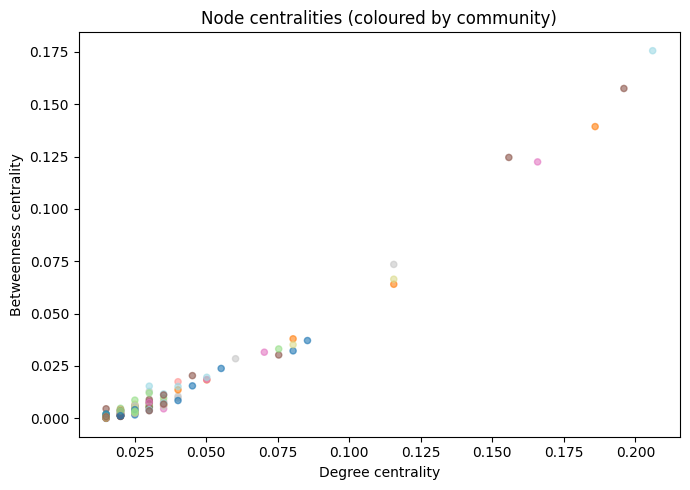

In [15]:
# Degree centrality: normalised degree
deg_centrality  = nx.degree_centrality(G)

# Betweenness centrality: fraction of shortest paths passing through node
# (expensive for large graphs — uses an approximate version for N > 500)
if N_nodes <= 500:
    bet_centrality = nx.betweenness_centrality(G, normalized=True)
else:
    bet_centrality = nx.betweenness_centrality(G, k=100, normalized=True)  # approximate

# Sort top hubs by degree centrality
top_hubs = sorted(deg_centrality, key=deg_centrality.get, reverse=True)[:10]
print("Top 10 hub nodes (by degree centrality):")
for node in top_hubs:
    print(f"  Node {node:4d}  |  degree centrality = {deg_centrality[node]:.4f}"
          f"  |  betweenness = {bet_centrality[node]:.4f}")

# ── Scatter: degree vs betweenness ─────────────────────────────
dc = np.array(list(deg_centrality.values()))
bc = np.array(list(bet_centrality.values()))

plt.figure(figsize=(7, 5))
plt.scatter(dc, bc, s=20, alpha=0.6, c=colors)
plt.xlabel("Degree centrality")
plt.ylabel("Betweenness centrality")
plt.title("Node centralities (coloured by community)")
plt.tight_layout()
plt.show()

## B6 — Adjacency Matrix Heatmap

Reordering nodes by community reveals **block structure** in the adjacency matrix — the signature of a modular network.

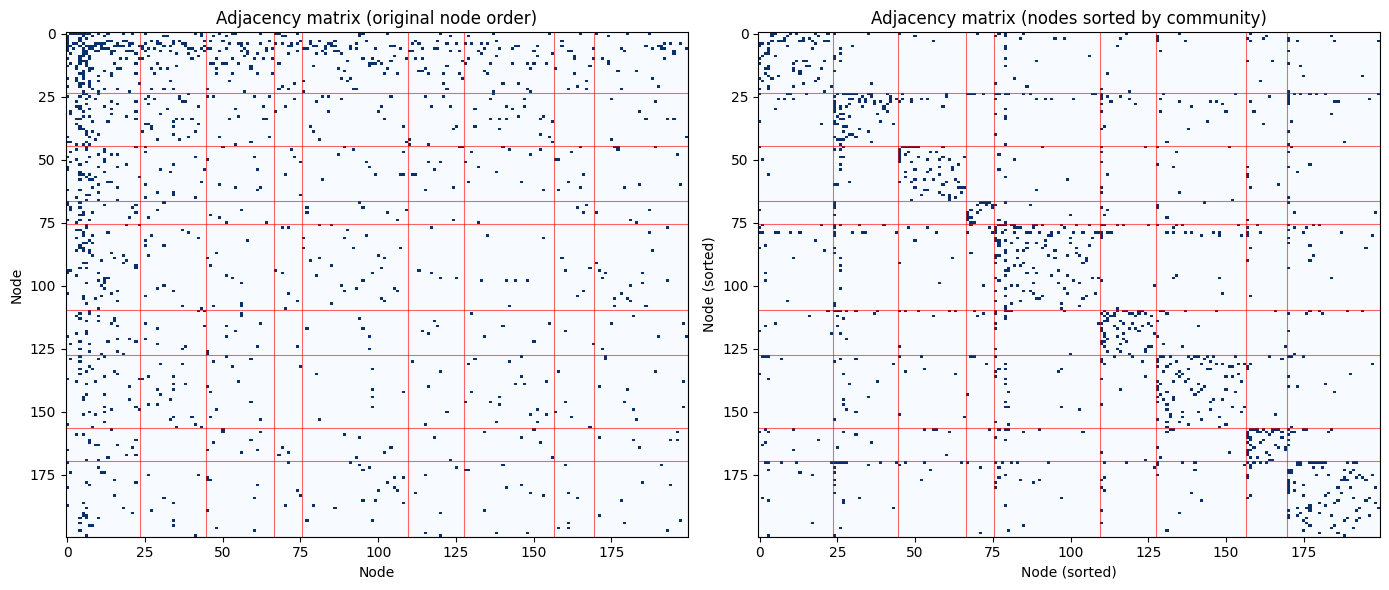

In [16]:
# Sort nodes by community
sorted_nodes = sorted(G.nodes(), key=lambda n: node_community[n])
A_matrix     = nx.to_numpy_array(G, nodelist=sorted_nodes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original ordering
A_orig = nx.to_numpy_array(G)
axes[0].imshow(A_orig, cmap='Blues', aspect='auto', interpolation='nearest')
axes[0].set_title("Adjacency matrix (original node order)")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

# Community-sorted ordering
axes[1].imshow(A_matrix, cmap='Blues', aspect='auto', interpolation='nearest')
axes[1].set_title("Adjacency matrix (nodes sorted by community)")
axes[1].set_xlabel("Node (sorted)")
axes[1].set_ylabel("Node (sorted)")

# Draw community boundaries
boundary = 0
for comm in communities:
    boundary += len(comm)
    for ax in axes:
        ax.axvline(boundary - 0.5, color='red', lw=0.8, alpha=0.6)
        ax.axhline(boundary - 0.5, color='red', lw=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

---
# CONVERGENCE — Use Real Connectivity as Reservoir Weights

As planned in the meeting, both teams converge here: we use the **brain connectivity graph** as the reservoir weight matrix `W`, instead of a random Gaussian matrix.

This tests whether the **topology of the human connectome** provides useful dynamics for the reservoir computing task.

Connectome reservoir size : 200 neurons
Spectral radius scaled to : 0.95
Connectome reservoir MSE  : 0.007708
Random Gaussian reservoir MSE : 0.044497


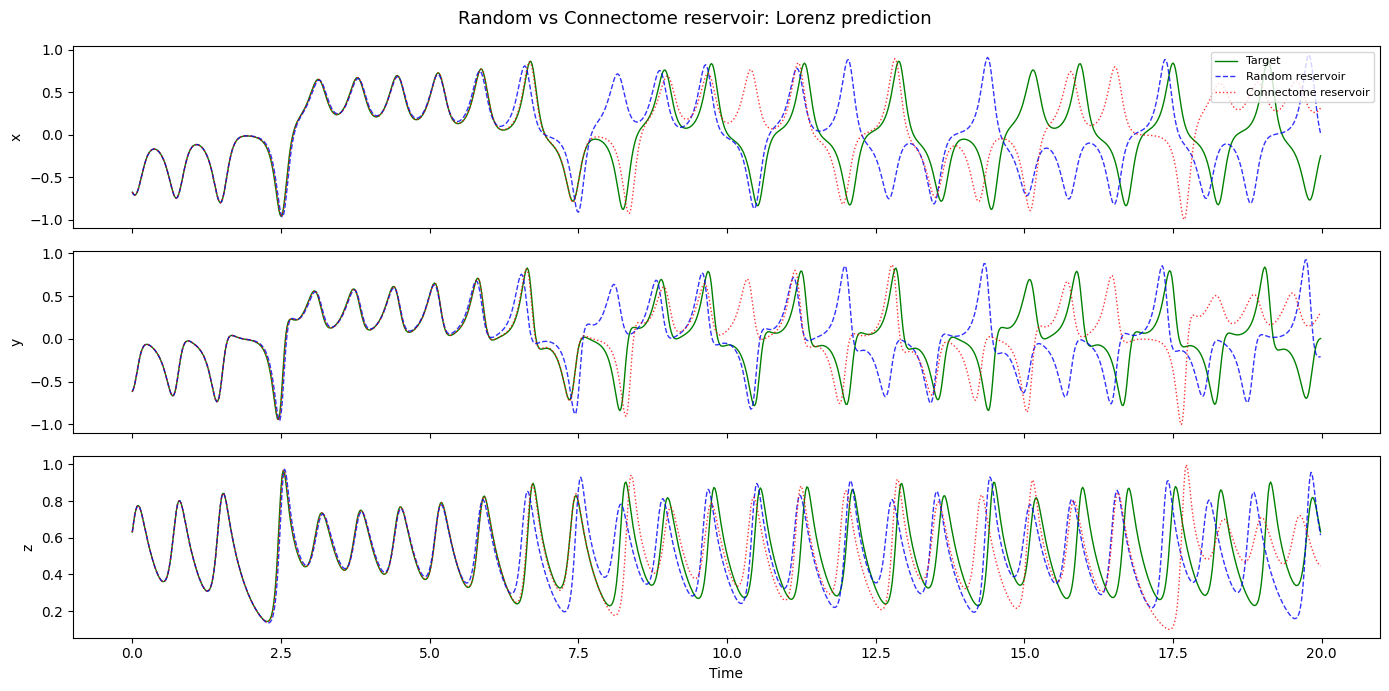

In [17]:
# Extract adjacency matrix from the graph and use as W
A_conn = nx.to_numpy_array(G, dtype=np.float64)

# Scale to desired spectral radius
rho_target = 0.95
eigs = linalg.eig(A_conn)[0]
spec_radius = max(abs(eigs))
if spec_radius > 0:
    A_conn_scaled = A_conn * (rho_target / spec_radius)
else:
    A_conn_scaled = A_conn

N_conn   = A_conn_scaled.shape[0]
print(f"Connectome reservoir size : {N_conn} neurons")
print(f"Spectral radius scaled to : {rho_target}")

# Build input matrix for this reservoir size
rng2     = np.random.default_rng(7)
Win_conn = (rng2.random((N_conn, 1 + inSize)) - 0.5)

# Run training phase with the connectome reservoir
X_conn  = np.zeros((1 + inSize + N_conn, trainLen - initLen))
Yt_conn = data_lorenz[initLen + 1 : trainLen + 1].T
r_conn  = np.zeros((N_conn, 1))

for t in range(trainLen):
    u = data_lorenz[t].reshape(-1, 1)
    bias_u = np.vstack([[1], u])
    r_conn = (1 - a) * r_conn + a * np.tanh(Win_conn @ bias_u + A_conn_scaled @ r_conn)
    if t >= initLen:
        X_conn[:, t - initLen] = np.vstack([[1], u, r_conn])[:, 0]

# Ridge regression
Wout_conn = linalg.solve(
    X_conn @ X_conn.T + reg * np.eye(1 + inSize + N_conn),
    X_conn @ Yt_conn.T
).T

# Generative test
Y_conn = np.zeros((outSize, testLen))
u = data_lorenz[trainLen].reshape(-1, 1)
for t in range(testLen):
    bias_u = np.vstack([[1], u])
    r_conn = (1 - a) * r_conn + a * np.tanh(Win_conn @ bias_u + A_conn_scaled @ r_conn)
    y      = Wout_conn @ np.vstack([[1], u, r_conn])
    Y_conn[:, t] = y[:, 0]
    u = y

mse_conn = np.mean((data_lorenz[trainLen + 1 : trainLen + errorLen + 1] - Y_conn[:, :errorLen].T) ** 2)
print(f"Connectome reservoir MSE  : {mse_conn:.6f}")
print(f"Random Gaussian reservoir MSE : {mse:.6f}")

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
t_axis = np.arange(testLen) * dt
for i, label in enumerate(['x', 'y', 'z']):
    axes[i].plot(t_axis, data_lorenz[trainLen + 1 : trainLen + testLen + 1, i],
                 'g', lw=1.0, label='Target')
    axes[i].plot(t_axis, Y[i], 'b--', lw=1.0, alpha=0.8, label='Random reservoir')
    axes[i].plot(t_axis, Y_conn[i], 'r:', lw=1.0, alpha=0.8, label='Connectome reservoir')
    axes[i].set_ylabel(label)
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time")
fig.suptitle("Random vs Connectome reservoir: Lorenz prediction", fontsize=13)
plt.tight_layout()
plt.show()